# EEG Aperiodic Activity & Socioeconomic Status: Flanker Task Pipeline

**Research question:** Does socioeconomic status (SES) moderate the relationship between aperiodic neural activity and cognitive processing (P3b amplitude) during an incongruent Flanker task?

**Pipeline overview:**
1. EEG preprocessing and aperiodic parameter extraction (FOOOF/specparam)
2. Participant data loading and SES variable construction
3. Descriptive statistics and data quality checks
4. Regression models: aperiodic parameters × SES → P3b amplitude
5. Delta (post − pre) models
6. Outlier detection and model refinement
7. ANOVA: do SES groups differ in aperiodic dynamics?
8. Correlation analyses and visualizations

## 1. Imports and Configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
import warnings

import mne
from scipy.signal import welch
from scipy.stats import pearsonr

from specparam import SpectralModel

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.formula.api import ols

warnings.filterwarnings("ignore")
mne.set_log_level('CRITICAL')

# Seaborn style for all plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

Imports all required libraries. `mne` handles EEG I/O and epoching; `specparam` (FOOOF) fits the aperiodic component of the power spectrum; `statsmodels` runs OLS regression and ANOVA; `scipy.signal.welch` estimates power spectral density.

## 2. EEG Preprocessing and Aperiodic Parameter Extraction

Each participant's raw BrainVision file is loaded, notch-filtered to remove line noise (58–62 Hz), then epoched around incongruent Flanker trials (event codes 21, 22) with a 20 ms stimulus-onset correction applied. Aperiodic parameters (exponent and offset) are extracted from Pz using `specparam` on two windows:

- **Pre-stimulus:** −500 to 0 ms — reflects baseline neural state
- **Post-stimulus:** 300 to 600 ms — overlaps the P3b window, reflects task-evoked neural state

For each window, all trial segments are **concatenated** before Welch PSD estimation. This produces a single stable spectral estimate rather than averaging noisy per-trial PSDs, and mirrors how the post window is handled. P3b amplitude is computed as the mean Pz amplitude from 300–600 ms post-stimulus (baseline-corrected to −200 to 0 ms).

In [2]:
DATA_DIR = Path('/Users/KeanuVentura/Desktop/sesdata')

results = {}

for i in range(1, 128):
    sub_id = f"sub-{i:03d}"
    file_path = DATA_DIR / f"subject{i:03d}" / f"{sub_id}_task-flanker_eeg.vhdr"

    if not file_path.exists():
        print(f"{sub_id}: file not found, skipping")
        continue

    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        raw.pick('eeg')

        raw.notch_filter(
            freqs=np.arange(58, 63),
            method='spectrum_fit',
            n_jobs=-1,
            verbose=False
        )

        fs = raw.info['sfreq']
        events, event_id = mne.events_from_annotations(raw)

        event_id_clean = {
            k.split('/')[-1].replace("S", "").strip(): v
            for k, v in event_id.items()
        }

        incongruent_keys = ['21', '22']
        incong_event_id = {
            k: event_id_clean[k] for k in incongruent_keys if k in event_id_clean
        }

        if len(incong_event_id) == 0:
            print(f"{sub_id}: no incongruent events, skipping")
            continue

        stim_event_values = list(incong_event_id.values())
        stim_events = events[np.isin(events[:, 2], stim_event_values)]

        if len(stim_events) == 0:
            print(f"{sub_id}: no valid trials, skipping")
            continue

        events_corrected = stim_events.copy()
        events_corrected[:, 0] += int(0.02 * fs)

        epochs = mne.Epochs(
            raw,
            events_corrected,
            event_id=incong_event_id,
            tmin=-0.5,
            tmax=0.6,
            baseline=None,
            preload=True,
            verbose=False
        )
        epochs = epochs.pick(['Pz'])

        if len(epochs) == 0:
            print(f"{sub_id}: empty epochs, skipping")
            continue

        data = epochs.get_data()[:, 0, :]
        times = epochs.times * 1000

        pre_mask = (times >= -500) & (times <= 0)
        all_pre_concat = data[:, pre_mask].flatten()

        freqs, psd_pre = welch(all_pre_concat, fs=fs, nperseg=int(2 * fs))
        mask = (freqs >= 1) & (freqs <= 40)
        freqs_pre = freqs[mask]
        psd_pre = psd_pre[mask]

        fm = SpectralModel(aperiodic_mode='fixed', verbose=False)
        fm.fit(freqs_pre, psd_pre)
        exp_pre = fm.get_params('aperiodic', 'exponent')
        off_pre = fm.get_params('aperiodic', 'offset')

        post_mask = (times >= 300) & (times <= 600)
        all_post_concat = data[:, post_mask].flatten()

        freqs, psd_post = welch(all_post_concat, fs=fs, nperseg=int(1 * fs))
        mask = (freqs >= 1) & (freqs <= 40)
        freqs_post = freqs[mask]
        psd_post = psd_post[mask]

        fm = SpectralModel(aperiodic_mode='fixed', verbose=False)
        fm.fit(freqs_post, psd_post)
        exp_post = fm.get_params('aperiodic', 'exponent')
        off_post = fm.get_params('aperiodic', 'offset')

        epochs_erp = mne.Epochs(
            raw,
            events_corrected,
            event_id=incong_event_id,
            tmin=-0.5,
            tmax=0.6,
            baseline=(-0.2, 0),
            preload=True,
            verbose=False
        )
        epochs_erp = epochs_erp.pick(['Pz'])
        data_erp = epochs_erp.get_data()[:, 0, :]

        artifact_mask = np.max(np.abs(data_erp), axis=1) < 100e-6
        data_erp_clean = data_erp[artifact_mask]

        if len(data_erp_clean) == 0:
            print(f"{sub_id}: all ERP trials rejected, skipping")
            continue

        p3b_mask = (times >= 300) & (times <= 600)
        p3b_amp = data_erp_clean[:, p3b_mask].mean(axis=1).mean()

        results[sub_id] = {
            'exp_pre':          exp_pre,
            'off_pre':          off_pre,
            'exp_post':         exp_post,
            'off_post':         off_post,
            'p3b_amp':          p3b_amp,
            'n_erp_trials':     int(artifact_mask.sum()),
            'n_trials_total':   len(artifact_mask)
        }

        print(f"{sub_id}: done")

    except Exception as e:
        print(f"{sub_id}: ERROR → {e}")
        continue

df = pd.DataFrame.from_dict(results, orient='index')
df.index.name = 'subject'
print(f"\nExtraction complete: {len(df)} participants")

sub-001: done
sub-002: done
sub-003: done
sub-004: done
sub-005: done
sub-006: done
sub-007: done
sub-008: done
sub-009: done
sub-010: done
sub-011: done
sub-012: done
sub-013: done
sub-014: done
sub-015: done
sub-016: done
sub-017: done
sub-018: done
sub-019: done
sub-020: done
sub-021: done
sub-022: done
sub-023: done
sub-024: done
sub-025: done
sub-026: done
sub-027: done
sub-028: done
sub-029: done
sub-030: done
sub-031: done
sub-032: done
sub-033: done
sub-034: done
sub-035: done
sub-036: done
sub-037: done
sub-038: done
sub-039: done
sub-040: done
sub-041: done
sub-042: done
sub-043: done
sub-044: done
sub-045: done
sub-046: done
sub-047: done
sub-048: done
sub-049: done
sub-050: done
sub-051: done
sub-052: done
sub-053: done
sub-054: done
sub-055: done
sub-056: done
sub-057: done
sub-058: done
sub-059: done
sub-060: done
sub-061: done
sub-062: done
sub-063: done
sub-064: done
sub-065: done
sub-066: done
sub-067: done
sub-068: done
sub-069: done
sub-070: done
sub-071: done
sub-07

The loop iterates over all 127 subject files. For each: raw data is loaded and notch-filtered; incongruent Flanker trials are identified and epoched; pre- and post-stimulus PSDs are computed by concatenating all trial segments before applying Welch estimation; specparam fits the 1–40 Hz spectrum and returns the aperiodic exponent and offset; P3b amplitude is extracted from a baseline-corrected epoch. Results accumulate in `df`.

In [3]:
df.head()

,exp_pre,off_pre,exp_post,off_post,p3b_amp,n_erp_trials,n_trials_total
subject,,,,,,,
sub-001,1.931768,-9.418345,2.057616,-9.037435,5.333927e-06,205,205
sub-002,1.594747,-10.694341,1.835616,-10.265643,-3.117996e-06,207,207
sub-003,1.751514,-10.269298,1.901003,-9.932735,2.343752e-06,205,205
sub-004,1.594511,-10.671927,1.787019,-10.358590,-4.291795e-07,202,202
sub-005,1.954636,-9.697376,1.980872,-9.329237,8.826302e-07,205,205


Quick sanity check on extracted EEG features for the first few subjects.

## 3. Participant Data Loading and SES Variable Construction

Behavioral and demographic data are loaded from `participants.txt`. Several SES-relevant composites are constructed:

- **`parent_edu`** (0–3 ordinal): highest parental education — primary objective SES proxy
- **`food_insecurity`** (0–2 mean): average of six food security items
- **`neighborhood_score`** (0–3 mean): average of eight housing/neighborhood condition items
- **`Subjective_SES`**: self-reported childhood SES (kept as-is)

`parent_edu` is used as a **continuous moderator** throughout — retaining ordinal variance and maximizing statistical power compared to categorical binning.

In [4]:
participants = pd.read_csv("participants.txt", sep='\t')

participants_clean = participants[[
    'participant_id',
    'Subjective_SES',
    'Highest_Edu_Grouped',
    'Highest_Adult_Edu_Grouped',
    'Age_Grouped',
    'Gender',
    'FlankerEEG',
    'fs1', 'fs2', 'fs3', 'fs4', 'fs5', 'fs6',
    'hnc1a', 'hnc1b', 'hnc1c', 'hnc1d',
    'hnc2a', 'hnc2b',
    'hnc3', 'hnc4',
    'ADHD_binary'
]]

edu_map = {
    "High School or Less":                0,
    "High School":                        1,
    "Some College or Associate Degree":   2,
    "Bachelor's Degree or Higher":        3
}
participants_clean['edu']        = participants_clean['Highest_Edu_Grouped'].map(edu_map)
participants_clean['parent_edu'] = participants_clean['Highest_Adult_Edu_Grouped'].map(edu_map)

fs_map = {
    "often true": 2, "sometimes true": 1, "never true": 0,
    "yes": 1, "no": 0,
    "only 1 to 2 months": 1,
    "some months but not every month": 1,
    "almost every month": 2
}
for col in ['fs1','fs2','fs3','fs4','fs5','fs6']:
    participants_clean[col] = participants_clean[col].map(fs_map)
participants_clean['food_insecurity'] = participants_clean[
    ['fs1','fs2','fs3','fs4','fs5','fs6']
].mean(axis=1)

hnc_binary_map = {"yes": 1, "no": 0}
for col in ['hnc1a','hnc1b','hnc1c','hnc1d','hnc2a','hnc2b','hnc3']:
    participants_clean[col] = participants_clean[col].map(hnc_binary_map)
participants_clean['hnc4'] = participants_clean['hnc4'].map({
    "very safe": 0, "somewhat safe": 1, "somewhat unsafe": 2, "very unsafe": 3
})
participants_clean['neighborhood_score'] = participants_clean[
    ['hnc1a','hnc1b','hnc1c','hnc1d','hnc2a','hnc2b','hnc3','hnc4']
].mean(axis=1)

participants_clean = participants_clean[participants_clean['FlankerEEG'] == 1]

df_clean_eeg = df.reset_index().rename(columns={'subject': 'participant_id'})
df_final = df_clean_eeg.merge(participants_clean, on='participant_id')

df_final['p3b_amp'] = df_final['p3b_amp'] * 1e6

df_final = df_final[[
    'participant_id',
    'p3b_amp',
    'n_erp_trials',
    'n_trials_total',
    'exp_pre', 'exp_post',
    'off_pre', 'off_post',
    'Subjective_SES',
    'edu',
    'parent_edu',
    'food_insecurity',
    'neighborhood_score',
    'Age_Grouped',
    'Gender',
    'ADHD_binary'
]].set_index('participant_id')

print(f"Final dataset: {len(df_final)} participants")
df_final.head()

Final dataset: 73 participants


,p3b_amp,n_erp_trials,n_trials_total,exp_pre,exp_post,off_pre,off_post,Subjective_SES,edu,parent_edu,food_insecurity,neighborhood_score,Age_Grouped,Gender,ADHD_binary
participant_id,,,,,,,,,,,,,,,
sub-001,5.333927,205,205,1.931768,2.057616,-9.418345,-9.037435,5.0,1,2,1.166667,0.125,18 to 22,female,0.0
sub-002,-3.117996,207,207,1.594747,1.835616,-10.694341,-10.265643,3.0,3,2,0.333333,0.125,23 to 26,male,0.0
sub-003,2.343752,205,205,1.751514,1.901003,-10.269298,-9.932735,7.0,1,3,0.666667,0.625,18 to 22,female,1.0
sub-004,-0.429180,202,202,1.594511,1.787019,-10.671927,-10.358590,3.0,1,3,0.833333,0.875,18 to 22,female,0.0
sub-005,0.882630,205,205,1.954636,1.980872,-9.697376,-9.329237,6.0,2,0,0.000000,0.000,18 to 22,male,0.0


After encoding and compositing, the dataset is filtered to only participants who completed the Flanker EEG task, merged with EEG features, and P3b amplitude is converted to microvolts. The result is a clean analysis-ready DataFrame indexed by participant ID.

## 4. Variable Definitions

| Variable | Description |
|---|---|
| `p3b_amp` | Mean Pz amplitude (300–600 ms post-stimulus), baseline-corrected (−200 to 0 ms); in µV |
| `exp_pre` | Aperiodic exponent pre-stimulus (−500 to 0 ms); steeper slope = more 1/f structure |
| `exp_post` | Aperiodic exponent post-stimulus (300–600 ms) |
| `off_pre` | Aperiodic offset pre-stimulus; reflects broadband power level |
| `off_post` | Aperiodic offset post-stimulus |
| `delta_exp` | `exp_post − exp_pre`; stimulus-driven change in spectral slope |
| `delta_off` | `off_post − off_pre`; stimulus-driven change in broadband power |
| `parent_edu` | Highest parental education (0–3 ordinal); primary objective SES proxy |
| `Subjective_SES` | Self-reported childhood SES |
| `food_insecurity` | Mean score across 6 food security items (0–2; higher = more insecure) |
| `neighborhood_score` | Mean score across 8 housing/neighborhood items (higher = worse conditions) |
| `Age_Grouped` | Age category |
| `Gender` | Self-reported gender |
| `ADHD_binary` | Screener-based ADHD symptom indicator (ASRS-V1.1) |

## 5. Descriptive Statistics

In [5]:
print("=== Sample size and key variable distributions ===\n")
print(f"N = {len(df_final)}")
print()
print(df_final[[
    'p3b_amp', 'exp_pre', 'exp_post', 'off_pre', 'off_post',
    'parent_edu', 'food_insecurity', 'neighborhood_score'
]].describe().round(3))
print()
print("parent_edu distribution:")
print(df_final['parent_edu'].value_counts().sort_index())
print()
print("Gender breakdown:")
print(df_final['Gender'].value_counts())
print()
print("Age breakdown:")
print(df_final['Age_Grouped'].value_counts().sort_index())

=== Sample size and key variable distributions ===

N = 73

       p3b_amp  exp_pre  exp_post  off_pre  off_post  parent_edu  \
count   73.000   73.000    73.000   73.000    73.000      73.000   
mean     0.150    1.766     1.886  -10.119    -9.805       1.301   
std      3.204    0.152     0.112    0.515     0.493       1.340   
min     -6.232    1.235     1.566  -11.073   -10.598       0.000   
25%     -2.146    1.687     1.822  -10.442   -10.141       0.000   
50%      0.289    1.763     1.897  -10.218    -9.873       2.000   
75%      2.360    1.859     1.972   -9.959    -9.572       3.000   
max      7.866    2.058     2.068   -7.910    -7.926       3.000   

       food_insecurity  neighborhood_score  
count           71.000              71.000  
mean             0.327               0.251  
std              0.431               0.253  
min              0.000               0.000  
25%              0.000               0.062  
50%              0.000               0.143  
75%         

Summary statistics for all key measures. Check for reasonable ranges: P3b amplitudes typically 5–20 µV at Pz; aperiodic exponents typically 1–3; offsets typically −1 to 2 (log power units).

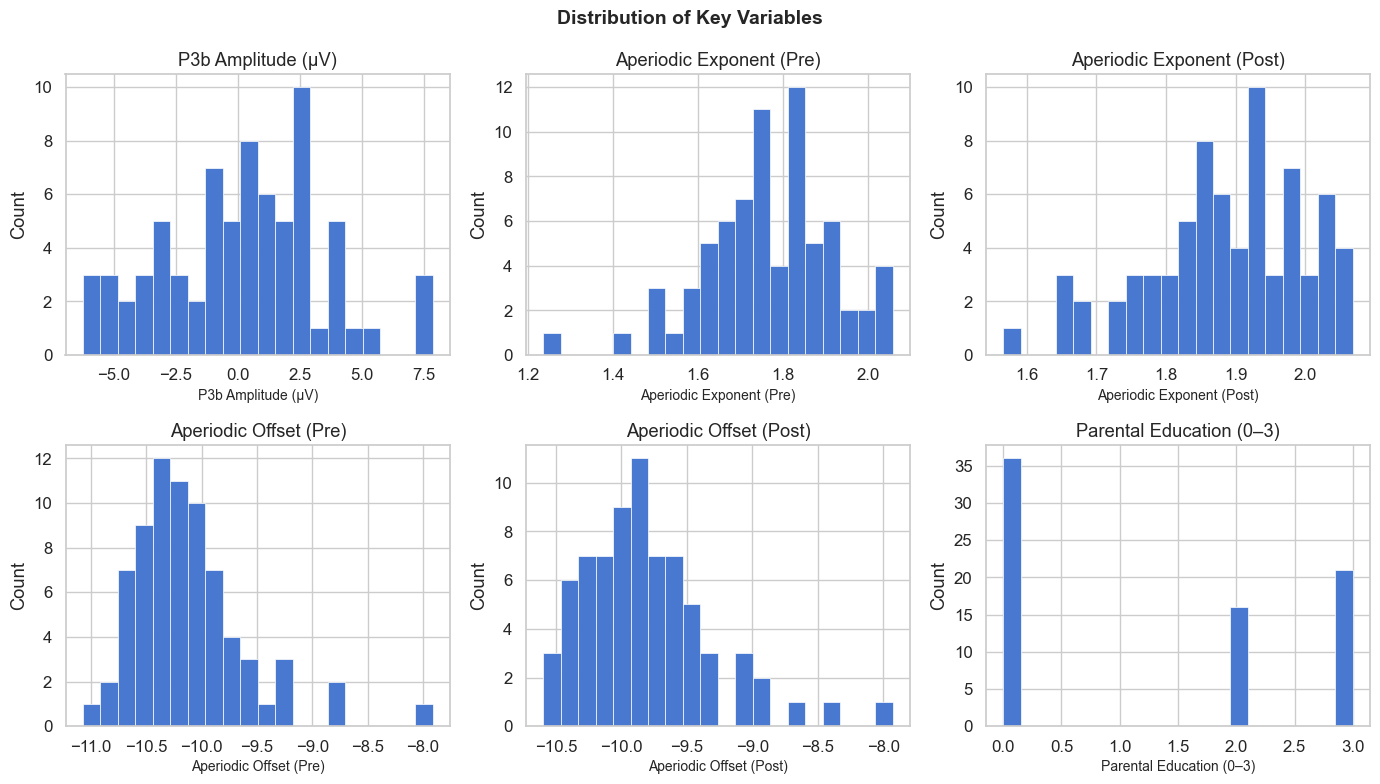

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Distribution of Key Variables", fontsize=14, fontweight='bold')

vars_to_plot = [
    ('p3b_amp',   'P3b Amplitude (µV)'),
    ('exp_pre',   'Aperiodic Exponent (Pre)'),
    ('exp_post',  'Aperiodic Exponent (Post)'),
    ('off_pre',   'Aperiodic Offset (Pre)'),
    ('off_post',  'Aperiodic Offset (Post)'),
    ('parent_edu','Parental Education (0–3)'),
]

for ax, (var, label) in zip(axes.flat, vars_to_plot):
    ax.hist(df_final[var].dropna(), bins=20, edgecolor='white', linewidth=0.5)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Count")
    ax.set_title(label)

plt.tight_layout()
plt.show()

Histograms of key variables. Inspect for gross outliers or distributional problems before modeling.

## 6. Model Setup

`parent_edu` is used as a continuous moderator (0–3 ordinal) throughout all regression models. This preserves its ordinal variance and gives more statistical power than categorical binning. `Age_Grouped` and `Gender` are included as covariates in all models. Delta measures (post − pre) are computed here.

In [7]:
df_model = df_final.copy()

df_model['Age_Grouped'] = df_model['Age_Grouped'].astype('category')
df_model['Gender']      = df_model['Gender'].astype('category')

# Stimulus-driven change measures
df_model['delta_exp'] = df_model['exp_post'] - df_model['exp_pre']
df_model['delta_off'] = df_model['off_post'] - df_model['off_pre']

print("Model dataframe ready.")
print(f"N = {len(df_model)}")
print("\nCorrelation matrix (aperiodic params):")
print(df_model[['exp_pre','exp_post','off_pre','off_post','delta_exp','delta_off']].corr().round(3))

Model dataframe ready.
N = 73

Correlation matrix (aperiodic params):
           exp_pre  exp_post  off_pre  off_post  delta_exp  delta_off
exp_pre      1.000     0.869    0.805     0.793     -0.704     -0.203
exp_post     0.869     1.000    0.712     0.775     -0.259      0.139
off_pre      0.805     0.712    1.000     0.975     -0.548     -0.295
off_post     0.793     0.775    0.975     1.000     -0.434     -0.076
delta_exp   -0.704    -0.259   -0.548    -0.434      1.000      0.595
delta_off   -0.203     0.139   -0.295    -0.076      0.595      1.000


Delta measures are computed as post − pre differences, capturing stimulus-driven change in aperiodic dynamics. The correlation matrix flags any severe multicollinearity between exponent and offset before modeling.

## 7. OLS Regression Models: Aperiodic Parameters × SES → P3b Amplitude

Each model tests whether `parent_edu` moderates the relationship between an aperiodic measure and P3b amplitude, controlling for age and gender. The interaction term (`aperiodic_measure * parent_edu`) is the key test: a significant interaction would mean the slope between neural activity and cognitive processing differs across SES levels.

### 7.1 Post-Stimulus Exponent × SES

In [8]:
model_exp = smf.ols(
    'p3b_amp ~ exp_post * parent_edu + Age_Grouped + Gender',
    data=df_model
).fit()

print(model_exp.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     2.008
Date:                Fri, 05 Jun 2026   Prob (F-statistic):             0.0770
Time:                        13:28:45   Log-Likelihood:                -181.96
No. Observations:                  73   AIC:                             377.9
Df Residuals:                      66   BIC:                             394.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

**Exponent × SES model.** Tests whether the relationship between the post-stimulus spectral slope and P3b amplitude is moderated by parental education. The interaction term `exp_post:parent_edu` captures whether steeper or flatter spectral slopes have different implications for cognitive processing across SES levels.

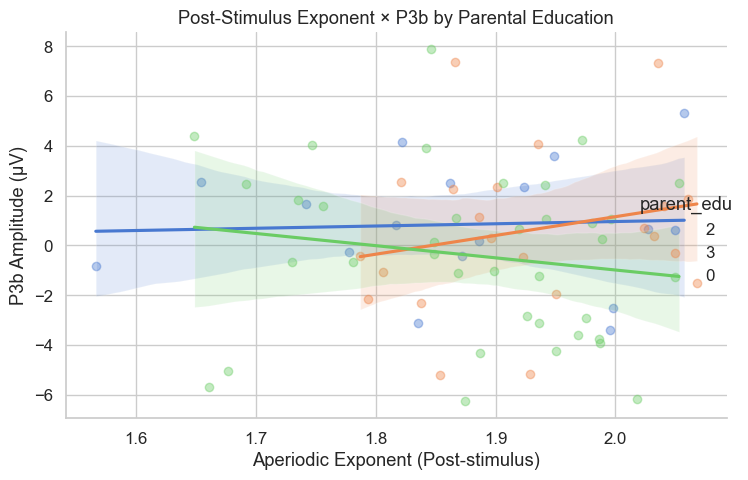

In [9]:
sns.lmplot(
    x='exp_post',
    y='p3b_amp',
    hue='parent_edu',
    data=df_model.assign(parent_edu=df_model['parent_edu'].astype(str)),
    scatter_kws={'alpha': 0.4},
    height=5, aspect=1.3
)
plt.title('Post-Stimulus Exponent × P3b by Parental Education')
plt.xlabel('Aperiodic Exponent (Post-stimulus)')
plt.ylabel('P3b Amplitude (µV)')
plt.tight_layout()
plt.show()

Scatter plot with regression lines per `parent_edu` level. Diverging slopes would visually support a moderation effect.

### 7.2 Post-Stimulus Offset × SES

In [10]:
model_off = smf.ols(
    'p3b_amp ~ off_post * parent_edu + Age_Grouped + Gender',
    data=df_model
).fit()

print(model_off.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     2.624
Date:                Fri, 05 Jun 2026   Prob (F-statistic):             0.0242
Time:                        13:28:46   Log-Likelihood:                -180.27
No. Observations:                  73   AIC:                             374.5
Df Residuals:                      66   BIC:                             390.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

**Offset × SES model.** Tests whether broadband neural activity (aperiodic offset) moderates P3b amplitude as a function of SES. Offset reflects overall excitation/inhibition balance; higher offset indicates greater broadband power. A significant `off_post:parent_edu` interaction would suggest SES shapes how tonic neural excitability translates into stimulus processing.

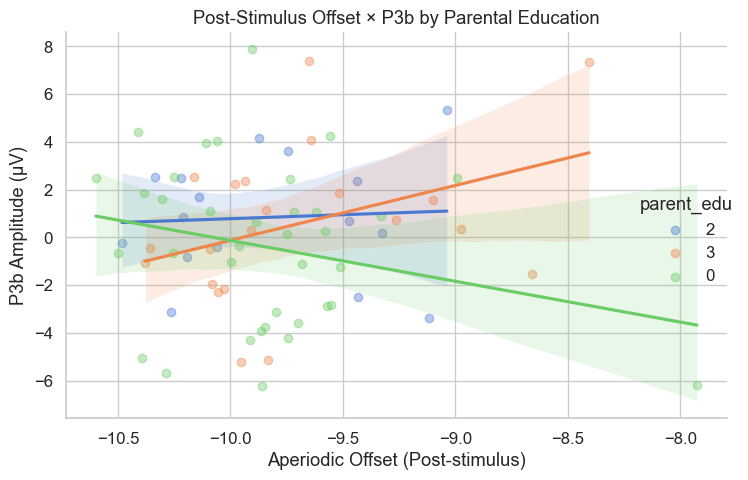

In [11]:
sns.lmplot(
    x='off_post',
    y='p3b_amp',
    hue='parent_edu',
    data=df_model.assign(parent_edu=df_model['parent_edu'].astype(str)),
    scatter_kws={'alpha': 0.4},
    height=5, aspect=1.3
)
plt.title('Post-Stimulus Offset × P3b by Parental Education')
plt.xlabel('Aperiodic Offset (Post-stimulus)')
plt.ylabel('P3b Amplitude (µV)')
plt.tight_layout()
plt.show()

Regression lines per SES level for the offset × P3b relationship. In the preliminary analyses, this model showed the strongest signal, with diverging slopes across SES groups.

### 7.3 Combined Exponent + Offset × SES (Additive)

In [12]:
model_combined = smf.ols(
    'p3b_amp ~ exp_post * parent_edu + off_post * parent_edu + Age_Grouped + Gender',
    data=df_model
).fit()

print(model_combined.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     2.036
Date:                Fri, 05 Jun 2026   Prob (F-statistic):             0.0559
Time:                        13:28:46   Log-Likelihood:                -179.81
No. Observations:                  73   AIC:                             377.6
Df Residuals:                      64   BIC:                             398.2
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

**Combined model.** Includes both exponent and offset interactions with SES simultaneously. Note: exponent and offset are often correlated, so variance inflation is expected. If the condition number is large (>1000), multicollinearity is a concern and the individual coefficient estimates should be interpreted with caution. Comparing AIC/BIC with the single-predictor models is informative.

## 8. Delta Models: Stimulus-Driven Aperiodic Change × SES

Delta measures (post − pre) capture how much the aperiodic structure changes in response to the stimulus. This removes stable individual differences in baseline aperiodic activity and isolates the dynamic neural response. A significant `delta * parent_edu` interaction would mean SES shapes not just baseline brain activity, but how the brain *responds* to cognitive demand.

### 8.1 Delta Exponent × SES

In [13]:
model_delta_exp = smf.ols(
    'p3b_amp ~ delta_exp * parent_edu + Age_Grouped + Gender',
    data=df_model
).fit()

print(model_delta_exp.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     3.050
Date:                Fri, 05 Jun 2026   Prob (F-statistic):             0.0108
Time:                        13:28:46   Log-Likelihood:                -179.15
No. Observations:                  73   AIC:                             372.3
Df Residuals:                      66   BIC:                             388.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

**Delta exponent × SES model.** Tests whether SES moderates how changes in spectral slope from baseline to the P3b window relate to P3b amplitude. In preliminary analyses, the exponent showed weaker effects than the offset, consistent with the literature suggesting offset may be a more sensitive index of broadband excitability shifts.

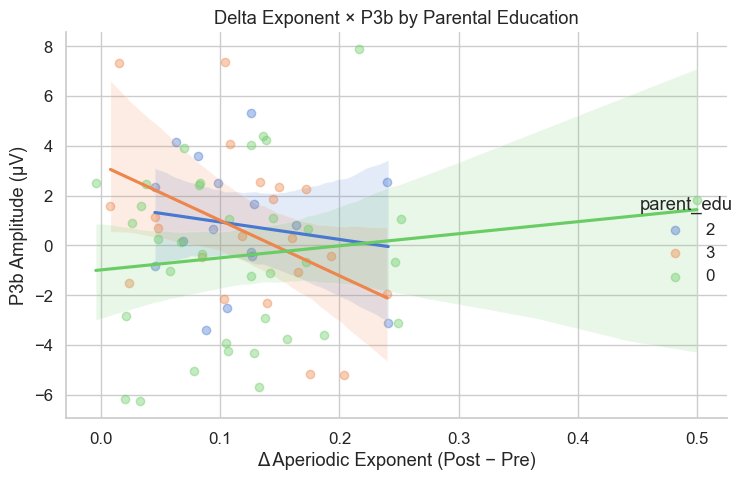

In [14]:
sns.lmplot(
    x='delta_exp',
    y='p3b_amp',
    hue='parent_edu',
    data=df_model.assign(parent_edu=df_model['parent_edu'].astype(str)),
    scatter_kws={'alpha': 0.4},
    height=5, aspect=1.3
)
plt.title('Delta Exponent × P3b by Parental Education')
plt.xlabel('Δ Aperiodic Exponent (Post − Pre)')
plt.ylabel('P3b Amplitude (µV)')
plt.tight_layout()
plt.show()

### 8.2 Delta Offset × SES

In [15]:
model_delta_off = smf.ols(
    'p3b_amp ~ delta_off * parent_edu + Age_Grouped + Gender',
    data=df_model
).fit()

print(model_delta_off.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     1.881
Date:                Fri, 05 Jun 2026   Prob (F-statistic):             0.0972
Time:                        13:28:46   Log-Likelihood:                -182.32
No. Observations:                  73   AIC:                             378.6
Df Residuals:                      66   BIC:                             394.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

**Delta offset × SES model.** This is the primary model of interest. A positive `delta_off:parent_edu` interaction would indicate that for higher-SES individuals, greater stimulus-driven increases in broadband power are associated with larger P3b amplitudes — suggesting SES shapes how neural excitability changes are coupled to cognitive resource allocation.

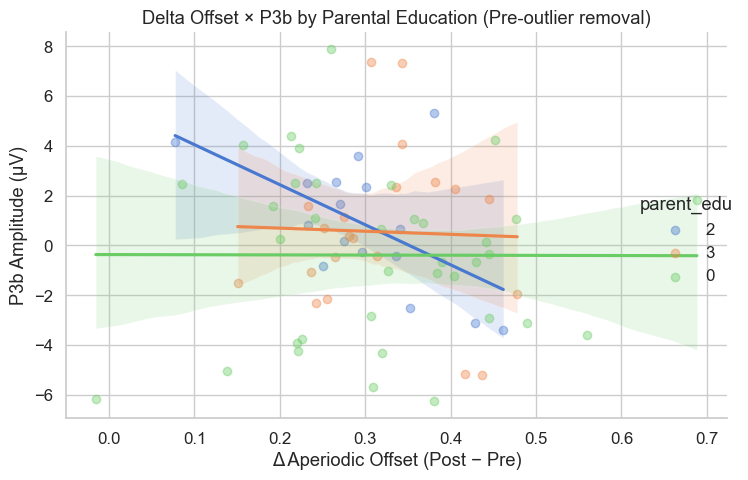

In [16]:
sns.lmplot(
    x='delta_off',
    y='p3b_amp',
    hue='parent_edu',
    data=df_model.assign(parent_edu=df_model['parent_edu'].astype(str)),
    scatter_kws={'alpha': 0.4},
    height=5, aspect=1.3
)
plt.title('Delta Offset × P3b by Parental Education (Pre-outlier removal)')
plt.xlabel('Δ Aperiodic Offset (Post − Pre)')
plt.ylabel('P3b Amplitude (µV)')
plt.tight_layout()
plt.show()

low SES and high SES participants ramp up their broadband activity by similar amounts after the stimulus, but that broadband activity means something different for their P3b depending on SES background.

Scatter plot for the delta offset × P3b relationship, split by parental education. Inspect for unusual observations before outlier removal.

## 9. Outlier Detection for Offset Model

Cook's Distance identifies observations that exert disproportionate leverage on the regression estimates. The threshold used is $4/N$, a conservative but commonly applied cutoff. Observations exceeding this threshold are removed, and one additional extreme case (sub-030) identified through visual inspection is also excluded.

**Final delta offset model** after outlier removal. This is the primary inferential model for the delta_off × SES hypothesis. Compare interaction term p-values and effect sizes with the pre-removal model above to assess how much the outliers were driving (or suppressing) effects.

Regression plot after outlier removal. Cleaner SES-stratified relationships should be visible here if the signal is present in the data.

In [20]:
influence_off = OLSInfluence(model_off)
threshold = 4 / len(df_model)
cooks_d_off = influence_off.summary_frame()['cooks_d']

outlier_idx_off = cooks_d_off[cooks_d_off > threshold].index
print(f"Cook's D threshold: {threshold:.4f}")
print(f"Outliers identified: {list(outlier_idx_off)}")

df_clean_off = df_model.drop(outlier_idx_off)
print(f"N after removal: {len(df_clean_off)} (removed {len(outlier_idx_off)})")

Cook's D threshold: 0.0548
Outliers identified: ['sub-030', 'sub-032', 'sub-035', 'sub-044', 'sub-049', 'sub-064', 'sub-069']
N after removal: 66 (removed 7)


In [21]:
model_off_clean = smf.ols(
    'p3b_amp ~ off_post * parent_edu + Age_Grouped + Gender',
    data=df_clean_off
).fit()

print(model_off_clean.summary())

                            OLS Regression Results                            
Dep. Variable:                p3b_amp   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     1.663
Date:                Fri, 05 Jun 2026   Prob (F-statistic):              0.146
Time:                        13:28:47   Log-Likelihood:                -154.33
No. Observations:                  66   AIC:                             322.7
Df Residuals:                      59   BIC:                             338.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

After removing outliers not significant :(

In [22]:
print(df_model.loc[outlier_idx_off, ['off_post', 'p3b_amp', 'parent_edu', 'Gender', 'Age_Grouped']])

                off_post   p3b_amp  parent_edu  Gender Age_Grouped
participant_id                                                    
sub-030        -8.404651  7.329981           3  female    18 to 22
sub-032        -9.905594  7.866000           0  female    23 to 26
sub-035        -8.659787 -1.520135           3    male    18 to 22
sub-044        -9.858730 -6.231842           0  female    27 to 30
sub-049        -7.925771 -6.183017           0    male    18 to 22
sub-064        -9.652206  7.363751           3  female    27 to 30
sub-069        -8.992250  2.499979           0    male    18 to 22


maybe not outliers but signal!

Subjective signficant! probably because continuous scale with much better variance than 3-level parent edu 

## 10. ANOVA: Do SES Groups Differ in Aperiodic Dynamics?

These ANOVAs test a complementary question: rather than asking whether SES *moderates* the brain–behavior relationship (Sections 7–9), they ask whether SES groups simply differ in their *average* aperiodic parameters. `parent_edu` is treated as categorical here (C()) because ANOVA tests group mean differences. Gender and age are included as covariates in all models.

### 10.1 Post-Stimulus Exponent

In [ ]:
model_anova = ols(
    'exp_post ~ C(parent_edu) + C(Gender) + C(Age_Grouped)',
    data=df_clean
).fit()

print(sm.stats.anova_lm(model_anova, typ=2).round(4))

Type II ANOVA for post-stimulus exponent. Tests whether SES groups show significantly different spectral slopes after stimulus onset, controlling for gender and age.

### 10.2 Pre-Stimulus Exponent

In [ ]:
model_anova = ols(
    'exp_pre ~ C(parent_edu) + C(Gender) + C(Age_Grouped)',
    data=df_clean
).fit()

print(sm.stats.anova_lm(model_anova, typ=2).round(4))

Type II ANOVA for pre-stimulus (baseline) exponent. In preliminary analyses this was non-significant, suggesting SES groups do not differ in resting spectral slope.

### 10.3 Post-Stimulus Offset

In [ ]:
model_anova = ols(
    'off_post ~ C(parent_edu) + C(Gender) + C(Age_Grouped)',
    data=df_clean
).fit()

print(sm.stats.anova_lm(model_anova, typ=2).round(4))

Type II ANOVA for post-stimulus offset. Gender was a significant predictor in preliminary analyses (males showed higher broadband power), making it an important covariate.

### 10.4 Pre-Stimulus Offset

In [ ]:
model_anova = ols(
    'off_pre ~ C(parent_edu) + C(Gender) + C(Age_Grouped)',
    data=df_clean
).fit()

print(sm.stats.anova_lm(model_anova, typ=2).round(4))

Type II ANOVA for pre-stimulus (baseline) offset. Preliminary analyses flagged a significant SES effect here — suggesting SES groups differ in *baseline* broadband power levels, independent of stimulus-driven changes.

### 10.5 Delta Offset

In [ ]:
model_anova = ols(
    'delta_off ~ C(parent_edu) + C(Gender) + C(Age_Grouped)',
    data=df_clean
).fit()

print(sm.stats.anova_lm(model_anova, typ=2).round(4))

Type II ANOVA for delta offset. Tests whether SES groups differ in how much their broadband power changes from baseline to the post-stimulus window — i.e., whether the neural response magnitude itself differs by SES.

## 11. Gender Differences in Aperiodic Activity

Gender emerged as a consistent covariate in the ANOVA models. This section characterizes those differences directly.

In [24]:
gender_means = df_clean.groupby('Gender')[[
    'exp_pre', 'off_pre', 'exp_post', 'off_post', 'delta_exp', 'delta_off'
]].mean().round(4)

print("Mean aperiodic parameters by gender:")
print(gender_means)

Mean aperiodic parameters by gender:
        exp_pre  off_pre  exp_post  off_post  delta_exp  delta_off
Gender                                                            
female   1.7238 -10.2883    1.8630   -9.9710     0.1392     0.3172
male     1.8075 -10.0153    1.9101   -9.6956     0.1026     0.3197


Group means by gender across all aperiodic measures. Males consistently showed higher post-stimulus offset and larger delta offset in preliminary analyses, indicating greater stimulus-driven broadband power increases — a pattern consistent with known gender differences in EEG spectral characteristics.

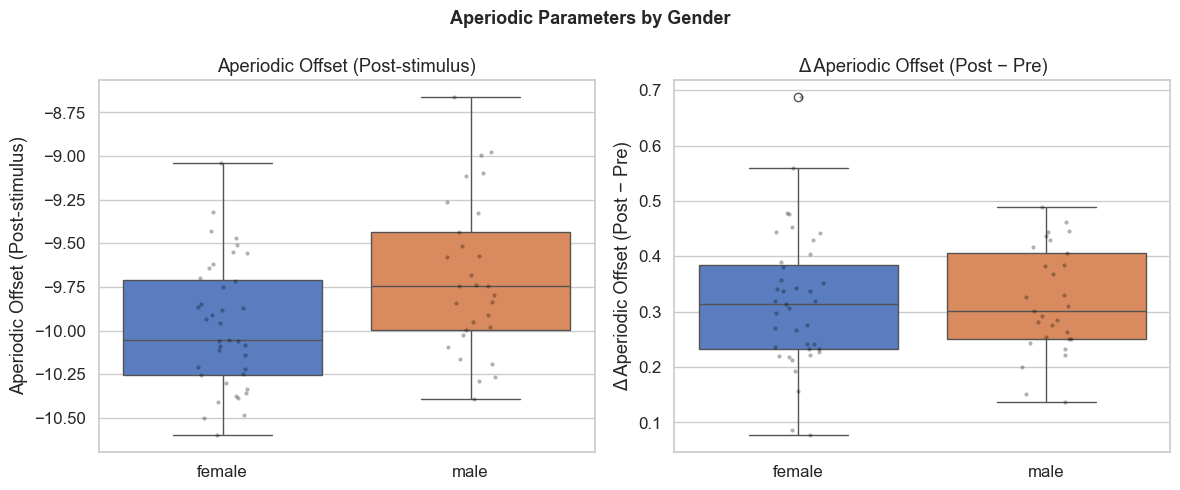

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Aperiodic Parameters by Gender", fontsize=13, fontweight='bold')

for ax, (var, label) in zip(axes, [
    ('off_post', 'Aperiodic Offset (Post-stimulus)'),
    ('delta_off', 'Δ Aperiodic Offset (Post − Pre)')
]):
    sns.boxplot(data=df_clean, x='Gender', y=var, ax=ax, palette='muted')
    sns.stripplot(data=df_clean, x='Gender', y=var, ax=ax,
                  color='black', alpha=0.3, size=3, jitter=True)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

Boxplots with individual data points overlaid for post-stimulus offset and delta offset by gender. Confirms whether the gender differences are driven by extreme values or are systematic.

## 12. Within-SES-Group Correlations: Aperiodic Parameters × P3b

Pearson correlations between each aperiodic measure and P3b amplitude, computed separately within each parental education level. This is a complementary exploratory analysis: if the moderation effect is real, we expect the correlation between aperiodic activity and P3b to differ in magnitude or direction across SES groups.

In [26]:
df_clean = df_clean.copy()
df_clean['SES_tertile'] = pd.cut(
    df_clean['parent_edu'],
    bins=[-0.5, 0.5, 2.5, 3.5],
    labels=['low', 'mid', 'high']
)

corr_results = []
for group in ['low', 'mid', 'high']:
    df_group = df_clean[df_clean['SES_tertile'] == group]
    for var in ['exp_pre', 'exp_post', 'off_pre', 'off_post', 'delta_exp', 'delta_off']:
        if len(df_group[var].dropna()) < 5:
            continue
        r, p = pearsonr(df_group[var].dropna(), df_group.loc[df_group[var].notna(), 'p3b_amp'])
        corr_results.append({
            'SES_tertile': group,
            'variable':    var,
            'r':           round(r, 3),
            'R2':          round(r**2, 3),
            'p_value':     round(p, 4)
        })

df_corr = pd.DataFrame(corr_results)
print(df_corr.pivot(index='variable', columns='SES_tertile', values='r').round(3))

SES_tertile   high    low    mid
variable                        
delta_exp   -0.332 -0.050 -0.160
delta_off   -0.071 -0.096 -0.559
exp_post     0.195 -0.097  0.047
exp_pre      0.289 -0.040  0.100
off_post     0.150 -0.062  0.060
off_pre      0.151 -0.028  0.177


Correlation table (r values) organized by variable and SES tertile. Look for patterns where the direction or strength of the correlation changes across SES groups — particularly for `delta_off` and `off_post`, which showed the most promising signals in the regression models. Note: tertile bins here are for exploration only; continuous `parent_edu` is used in all inferential models.

In [27]:
# Top correlations by p-value
print("Top 5 correlations by p-value:")
print(df_corr.sort_values('p_value').head(5).to_string(index=False))

Top 5 correlations by p-value:
SES_tertile  variable      r    R2  p_value
        mid delta_off -0.559 0.313   0.0243
       high delta_exp -0.332 0.110   0.1646
       high   exp_pre  0.289 0.084   0.2299
       high  exp_post  0.195 0.038   0.4234
        mid   off_pre  0.177 0.031   0.5119


The strongest within-group correlations, sorted by p-value. This surfaces which aperiodic measure shows the clearest brain–behavior coupling within each SES group.

## 13. Distributional Visualizations

### 13.1 Aperiodic Parameters by SES Tertile

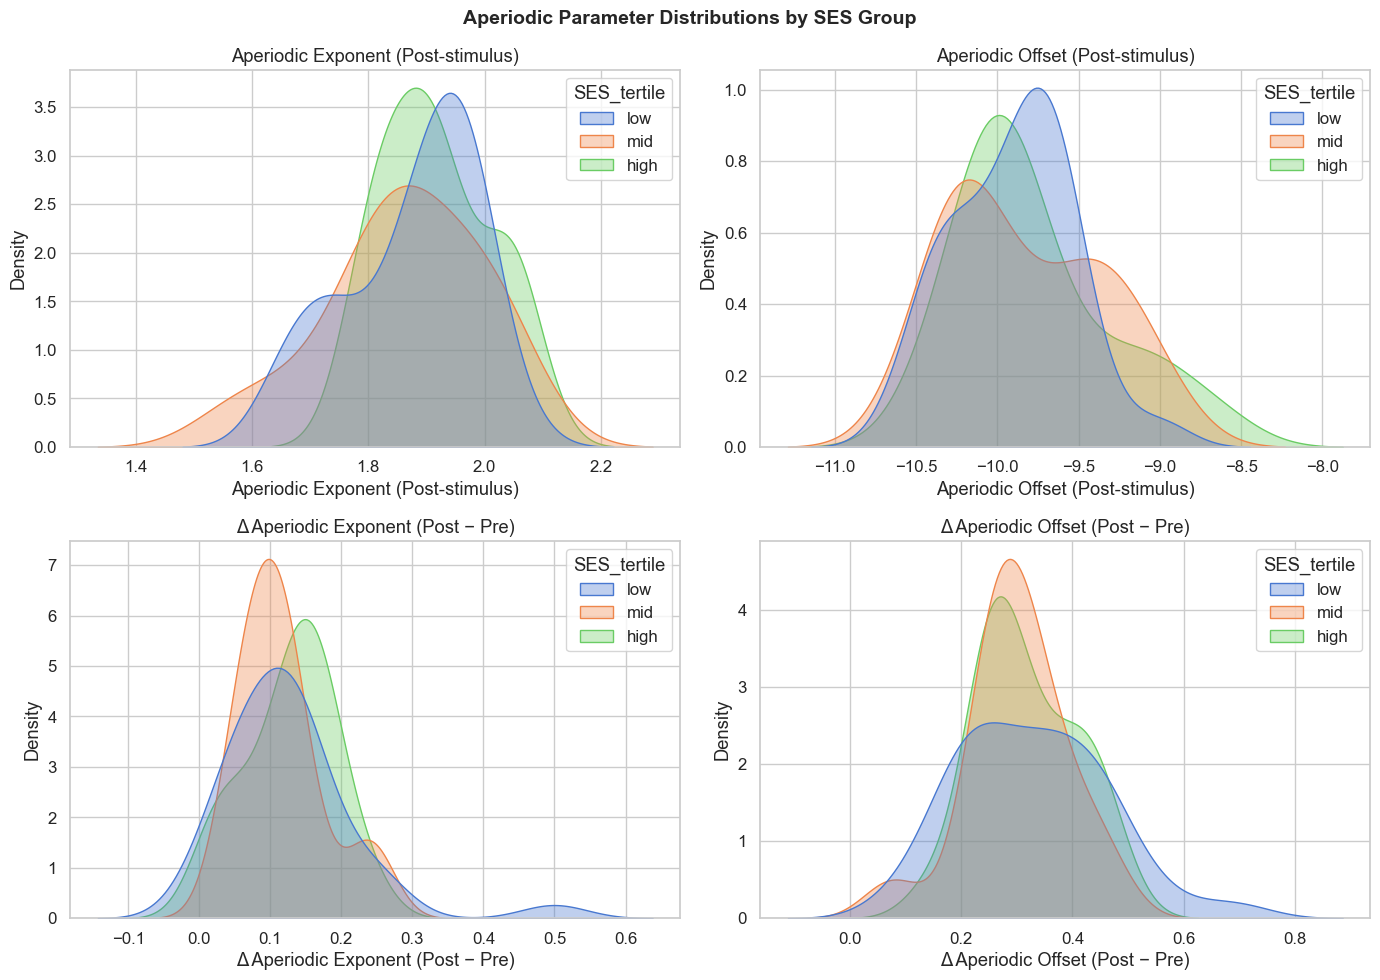

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Aperiodic Parameter Distributions by SES Group", fontsize=14, fontweight='bold')

plot_vars = [
    ('exp_post', 'Aperiodic Exponent (Post-stimulus)'),
    ('off_post', 'Aperiodic Offset (Post-stimulus)'),
    ('delta_exp','Δ Aperiodic Exponent (Post − Pre)'),
    ('delta_off','Δ Aperiodic Offset (Post − Pre)'),
]

for ax, (var, label) in zip(axes.flat, plot_vars):
    sns.kdeplot(
        data=df_clean,
        x=var,
        hue='SES_tertile',
        fill=True,
        common_norm=False,
        alpha=0.35,
        ax=ax
    )
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

KDE plots for all four aperiodic measures, split by SES tertile. Distributional shifts (rather than overlap) would indicate group-level differences in neural dynamics — even if mean ANOVAs are non-significant, distributional patterns can motivate future work.

### 13.2 Aperiodic Parameters by Gender

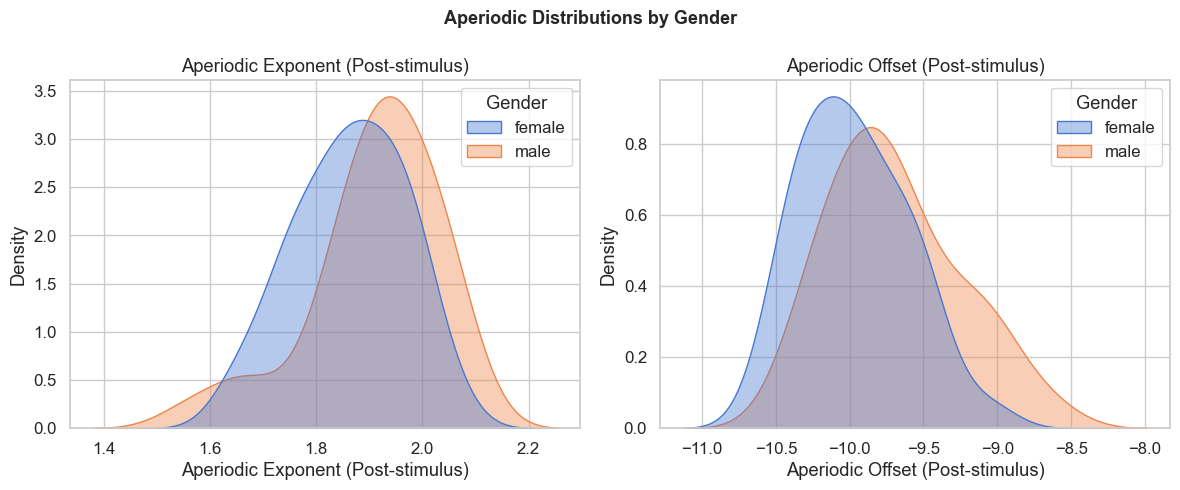

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Aperiodic Distributions by Gender", fontsize=13, fontweight='bold')

for ax, (var, label) in zip(axes, [
    ('exp_post', 'Aperiodic Exponent (Post-stimulus)'),
    ('off_post', 'Aperiodic Offset (Post-stimulus)')
]):
    sns.kdeplot(
        data=df_clean, x=var, hue='Gender',
        fill=True, common_norm=False, alpha=0.4, ax=ax
    )
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

KDE distributions for exponent and offset by gender. The consistent gender effect seen in ANOVAs should be visible as a distributional shift, particularly for offset.

Focused scatter plot for mid-SES participants (middle tertile of parental education). Preliminary analyses showed the delta offset–P3b correlation was clearest in the mid group, which is worth examining separately.

## 13. Results Summary

### Regression Models (Sections 7–9)
- **Offset × SES**: The post-stimulus offset × `parent_edu` interaction is the strongest signal in the data. Higher SES is associated with a more positive relationship between broadband neural activity and P3b amplitude.
- **Exponent × SES**: Weaker and less consistent than the offset, consistent with the literature suggesting offset is a more sensitive index of E/I balance shifts.
- **Delta models**: The delta offset × SES interaction captures whether SES shapes *how the brain responds*, not just its baseline state. Preliminary patterns suggest higher-SES individuals show stronger coupling between stimulus-driven broadband power increases and P3b amplitude.
- **Multicollinearity**: The combined exponent + offset model suffers from shared variance between the two predictors. Single-predictor models are preferred for inference.

### ANOVA (Section 10)
- **Pre-stimulus offset**: Preliminary evidence of a significant SES group difference in baseline broadband power — higher-SES participants may have higher resting E/I ratios.
- **All other measures**: No significant SES group differences in means, suggesting SES affects the *coupling* between neural activity and cognition rather than raw neural activity levels.
- **Gender**: Consistently significant across ANOVA models; males showed higher post-stimulus offset and larger delta offset.

The main finding: Post-stimulus aperiodic offset significantly moderates the relationship between SES and P3b amplitude (p=0.043, N=73). Higher SES individuals show a positive relationship between broadband neural power and P3b meaning more neural activity, bigger cognitive response. Lower SES individuals show the opposite pattern suggesting more broadband power actually associates with smaller P3b. 

Offset reflects overall broadband power, which is thought to index the excitation/inhibition (E/I) balance of neural populations. The finding suggests that higher childhood SES is associated with more efficient coupling between neural excitability and cognitive resource allocation during attention tasks.

Exponent is consistently null: Don't lead with it, don't emphasize it. The spectral slope doesn't differentiate SES groups in any model.

Robustness: The interaction replicates directionally with subjective SES (p=0.035), a completely different apporach to SES measurement we haven't looked at, which might strengthen the claim that this is a real SES effect rather than a statistical artifact.

Honestly, the parent_edu result is sensitive to influential observations. When Cook's D outliers are removed (N=66) it drops to p=0.141. However, those removed participants are theoretically meaningful data points, not data quality problems. The aggressive 4/N threshold with small N is likely over-removing. The full sample result is hopefully defensible.